# Notebook 09 — Front MOT Ground-Truth Evaluation

## Mục tiêu

Tạo **ground truth tracking thủ công** trên một tập nhỏ nhưng đại diện, sau đó đánh giá **ByteTrack B15** và **BoT-SORT** trên đúng cùng ground truth.

### Bộ GT rút gọn: 200 frame tổng cộng

Mỗi điều kiện giữ **1 đoạn liên tục 50 frame**. Các đoạn được lấy ở phần trung tâm của khoảng thời gian USER đã xem và xác nhận trước đó; không lấy rải rác từng frame để vẫn đánh giá được tính liên tục của ID.

| Video | Segment | Điều kiện | Frames | Số frame |
|---|---|---|---:|---:|
| V4_BREEDING | S2_SHELTER_TRANSITION | 1 cá, chuyển tiếp vào hang | 947–996 | 50 |
| V8_PAIR_T1 | P1_PAIR_INTERACTION | 2 cá tương tác/giao nhau | 243–292 | 50 |
| V5_NORMAL | M2_CROSSING | 8 cá bình thường, crossing | 303–352 | 50 |
| V3_FEEDING | F1_FEEDING_DENSE | 8 cá trong điều kiện cho ăn | 1184–1233 | 50 |

Tổng cộng: **200 frame** cần review.

## Vì sao rút còn 200 frame?

Notebook 09 dùng để **đánh giá tracker**, không phải để xây một dataset lớn. V4 đã có nhiều evidence ở các notebook trước; phần có giá trị nhất ở đây là các tình huống mất dấu/che khuất và duy trì identity. Vì vậy, 4 đoạn liên tục đại diện cho 4 mức độ/tình huống là đủ hợp lý cho một benchmark thủ công quy mô nhỏ.

## Nguyên tắc khoa học

- **GT bbox** là bbox do người nghiên cứu xác nhận từ raw frame, không phải bbox của YOLO/tracker.
- **GT ID** là biological identity trong *một segment*, không phải `track_id` do tracker sinh ra.
- Không copy prediction bbox hoặc prediction track ID vào GT.
- Frame đã xem nhưng không có cá đủ rõ để định vị bbox vẫn được đánh dấu `REVIEWED` với **0 GT objects**.
- Nếu identity sau che khuất không chắc chắn, dùng `UNCERTAIN`, không đoán.
- V4 chỉ có một cá: `GT ID = 1` khi cá localizable.
- `Copy previous GT` chỉ là **gợi ý thủ công từ GT frame trước đã REVIEWED**; không tự Save và không tự REVIEWED.
- Notebook 09 là **evaluation**, không tune tracker.
- Matching: **LAPJV one-to-one tại IoU = 0.50**.
- Không tự triển khai HOTA.


In [1]:

# ============================================================
# 0. SETUP
# ============================================================
from pathlib import Path
import hashlib, json, sys, time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/home/diy-hus/fish')
assert PROJECT_ROOT.exists(), PROJECT_ROOT

RESULTS_DIR = PROJECT_ROOT / 'results/tracking'
LOG_DIR = PROJECT_ROOT / 'logs/tracking/FRONT_MOT_GT_EVAL_001'
REVIEW_ROOT = PROJECT_ROOT / 'outputs/front/mot_groundtruth_review'
PRED_ROOT = PROJECT_ROOT / 'outputs/front/mot_eval/predictions'
for p in [RESULTS_DIR, LOG_DIR, REVIEW_ROOT, PRED_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

GT_OBJECT_PATH = RESULTS_DIR / 'front_mot_groundtruth.csv'
GT_REVIEW_PATH = RESULTS_DIR / 'front_mot_groundtruth_frame_review.csv'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('Python:', sys.version.split()[0])
print('OpenCV:', cv2.__version__)
print('pandas:', pd.__version__)


PROJECT_ROOT: /home/diy-hus/fish
Python: 3.11.15
OpenCV: 4.10.0
pandas: 3.0.5


In [16]:

# ============================================================
# 1. CONFIG — ĐÃ CHỐT
# ============================================================
EXPERIMENT_ID = 'FRONT_MOT_GT_EVAL_001'

VIDEO_REGISTRY = {
    'V4_BREEDING': {
        'filename': '4.mp4', 'fish_count': 1,
        'group': 'SINGLE_FISH_BREEDING',
        'condition': 'BREEDING_PARENTAL_CARE',
        'expected_sha256': '3f8587344beba8dcc6f835d1ed94aa8daadb06a369b5b96977ee902f035b5700',
    },
    'V8_PAIR_T1': {
        'filename': '8.mp4', 'fish_count': 2,
        'group': 'MULTI_FISH_PAIR', 'condition': 'PAIR_T1',
        'expected_sha256': '1eda257c757b0f7065c48b19888f9fad232b803322c1e2df85884c3d7ebd94be',
    },
    'V5_NORMAL': {
        'filename': '5.mp4', 'fish_count': 8,
        'group': 'MULTI_FISH_NORMAL', 'condition': 'NORMAL',
        'expected_sha256': '670c1360862953ad7f74eeb2208f1f9ff596a2241d7aed69c53175f9113e520c',
    },
    'V3_FEEDING': {
        'filename': '3.mp4', 'fish_count': 8,
        'group': 'MULTI_FISH_FEEDING', 'condition': 'FEEDING',
        'expected_sha256': 'f123b08e6e9ef50e8d4873c4c3bf417083cd105af1a08696013af312cf8b7411',
    },
}

EVAL_SEGMENTS = [
    {'video_id':'V4_BREEDING','segment_id':'S2_SHELTER_TRANSITION','scenario':'SHELTER_APPROACH','start_frame':947,'end_frame':996},
    {'video_id':'V8_PAIR_T1','segment_id':'P1_PAIR_INTERACTION','scenario':'PAIR_INTERACTION','start_frame':243,'end_frame':292},
    {'video_id':'V5_NORMAL','segment_id':'M2_CROSSING','scenario':'CROSSING','start_frame':303,'end_frame':352},
    {'video_id':'V3_FEEDING','segment_id':'F1_FEEDING_DENSE','scenario':'FEEDING_DENSE','start_frame':1184,'end_frame':1233},
]

MODEL_PATH = PROJECT_ROOT / 'runs/front/yolov8n_front_v1_baseline/weights/best.pt'
EXPECTED_MODEL_SHA256 = '750b0f8a1621f7214c8122467e5360ada69673ae4a8dc5bf3fd7b1e280287738'
TRACKER_CONFIGS = {
    'BYTE_B15': PROJECT_ROOT / 'configs/trackers/front_bytetrack_b15.yaml',
    'BOTSORT': PROJECT_ROOT / 'configs/trackers/front_botsort_benchmark.yaml',
}
DETECTION_FLOOR = 0.50
MATCH_IOU_THRESHOLD = 0.50
IMGSZ = 640
DEVICE = 0
RUN_TRACKERS = True  # chỉ đổi True sau khi GT_COMPLETE=True

EXPECTED_SELECTED_FRAMES = sum(s['end_frame']-s['start_frame']+1 for s in EVAL_SEGMENTS)
print('Selected frames:', EXPECTED_SELECTED_FRAMES)
assert EXPECTED_SELECTED_FRAMES == 200


Selected frames: 200


In [3]:

# ============================================================
# 2. PREPARE RAW FRAMES + REVIEW MANIFEST
# ============================================================
def sha256_file(path, chunk_size=1024*1024):
    h = hashlib.sha256()
    with open(path,'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()

def segment_lookup(video_id, segment_id):
    for s in EVAL_SEGMENTS:
        if s['video_id']==video_id and s['segment_id']==segment_id:
            return s
    raise KeyError((video_id,segment_id))

VIDEO_META={}
for video_id,cfg in VIDEO_REGISTRY.items():
    path = PROJECT_ROOT/'data/raw/front'/cfg['filename']
    assert path.is_file(), f'Missing video: {path}'
    digest = sha256_file(path)
    assert digest == cfg['expected_sha256'], f'SHA mismatch: {video_id}'
    cap=cv2.VideoCapture(str(path))
    fps=float(cap.get(cv2.CAP_PROP_FPS)); frames=int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); height=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    VIDEO_META[video_id]={'path':path,'sha256':digest,'fps':fps,'frame_count':frames,'width':width,'height':height,'duration_sec':frames/fps}
    print(video_id, VIDEO_META[video_id])

review_rows=[]
for seg in EVAL_SEGMENTS:
    video_id=seg['video_id']; meta=VIDEO_META[video_id]
    out_dir=REVIEW_ROOT/video_id/seg['segment_id']; out_dir.mkdir(parents=True,exist_ok=True)
    cap=cv2.VideoCapture(str(meta['path'])); cap.set(cv2.CAP_PROP_POS_FRAMES, seg['start_frame'])
    for frame_index in range(seg['start_frame'], seg['end_frame']+1):
        ok,frame=cap.read()
        if not ok: raise RuntimeError(f'Cannot read {video_id} frame {frame_index}')
        out_path=out_dir/f'frame_{frame_index:06d}.jpg'
        if not out_path.exists(): cv2.imwrite(str(out_path),frame)
        review_rows.append({'video_id':video_id,'segment_id':seg['segment_id'],'frame_index':frame_index,'time_sec':frame_index/meta['fps'],'review_status':'UNREVIEWED','review_note':''})
    cap.release()
    print('Raw frames ready:', video_id, seg['segment_id'])

expected=pd.DataFrame(review_rows)
if GT_REVIEW_PATH.exists():
    old=pd.read_csv(GT_REVIEW_PATH)
    old=old[[c for c in ['video_id','segment_id','frame_index','review_status','review_note'] if c in old.columns]].copy()
    merged=expected.merge(old,on=['video_id','segment_id','frame_index'],how='left',suffixes=('','_old'))
    if 'review_status_old' in merged: merged['review_status']=merged['review_status_old'].fillna(merged['review_status']); merged.drop(columns=['review_status_old'],inplace=True)
    if 'review_note_old' in merged: merged['review_note']=merged['review_note_old'].fillna(merged['review_note']); merged.drop(columns=['review_note_old'],inplace=True)
    review_df=merged
else:
    review_df=expected
review_df['review_status']=review_df['review_status'].fillna('UNREVIEWED').astype('object')
review_df['review_note']=review_df['review_note'].astype('object')
review_df.to_csv(GT_REVIEW_PATH,index=False,na_rep='')

GT_COLUMNS=['video_id','video_sha256','group','segment_id','scenario','frame_index','time_sec','gt_track_id','x1','y1','x2','y2','identity_certainty','visibility_note','annotation_note']
if not GT_OBJECT_PATH.exists(): pd.DataFrame(columns=GT_COLUMNS).to_csv(GT_OBJECT_PATH,index=False)

print('GT review manifest:', GT_REVIEW_PATH)
print('GT object file:', GT_OBJECT_PATH)
print('Review rows:', len(review_df))
assert len(review_df)==200


V4_BREEDING {'path': PosixPath('/home/diy-hus/fish/data/raw/front/4.mp4'), 'sha256': '3f8587344beba8dcc6f835d1ed94aa8daadb06a369b5b96977ee902f035b5700', 'fps': 28.66843196767745, 'frame_count': 3431, 'width': 1280, 'height': 960, 'duration_sec': 119.67867666666668}
V8_PAIR_T1 {'path': PosixPath('/home/diy-hus/fish/data/raw/front/8.mp4'), 'sha256': '1eda257c757b0f7065c48b19888f9fad232b803322c1e2df85884c3d7ebd94be', 'fps': 23.249407371763724, 'frame_count': 1380, 'width': 1280, 'height': 960, 'duration_sec': 59.35635166666667}
V5_NORMAL {'path': PosixPath('/home/diy-hus/fish/data/raw/front/5.mp4'), 'sha256': '670c1360862953ad7f74eeb2208f1f9ff596a2241d7aed69c53175f9113e520c', 'fps': 28.482163952365216, 'frame_count': 3413, 'width': 1280, 'height': 960, 'duration_sec': 119.82937833333332}
V3_FEEDING {'path': PosixPath('/home/diy-hus/fish/data/raw/front/3.mp4'), 'sha256': 'f123b08e6e9ef50e8d4873c4c3bf417083cd105af1a08696013af312cf8b7411', 'fps': 28.442006717026118, 'frame_count': 3410, 'wid

## 3. Gán GT bằng giao diện — single figure

Cell 3B dưới đây chỉ tạo **một Figure duy nhất** và tái sử dụng Figure đó cho mọi frame.

Quy trình cho mỗi frame:
1. Chọn segment.
2. Bấm **Load next unreviewed**.
3. Kéo chuột trái quanh cá trên Figure duy nhất.
4. Chờ dòng **Selected bbox: x1=..., y1=..., x2=..., y2=...**.
5. Điền `GT ID`, chọn `CERTAIN/UNCERTAIN`.
6. Bấm **Add selected bbox**.
7. Nếu có nhiều cá, lặp bước 3–6.
8. Bấm **Save frame + REVIEWED**.

Quy ước ID:
- V4: luôn `GT ID = 1`.
- V8: giữ ổn định ID 1,2 trong segment.
- V5/V3: giữ ID ổn định trong segment; nếu không chắc sau che khuất thì chọn `UNCERTAIN`, không đoán.
- Frame không có cá localizable: không Add bbox, chỉ bấm **Save frame + REVIEWED**.

Nếu frame đã có object từ một lần thử trước, GUI sẽ ghi rõ đó là **existing GT object**. Bạn có thể giữ, vẽ lại cùng GT ID để thay bbox cũ, hoặc bấm **Clear staged objects** rồi gán lại trước khi Save.

### Lưu ý về GT ID
- Khi bấm **Add selected bbox**, ô `GT ID` **không tự tăng**.
- Khi load một frame mới, `GT ID` được reset về **1**.
- V4: giữ `GT ID = 1`.
- V8/V5/V3: sau khi Add cá 1, USER tự đổi `GT ID` sang 2, 3, ... trước khi Add cá tiếp theo.


### Copy previous GT
- Nút **Copy previous GT** sao chép GT object từ frame `REVIEWED` gần nhất trước đó trong cùng segment.
- Chức năng này chỉ tạo **staging** để giảm thao tác ở các frame liên tiếp.
- Nó **không** ghi CSV, **không** tự đánh dấu `REVIEWED`, **không** dùng bbox/ID prediction.
- Sau khi copy, USER phải nhìn raw frame hiện tại, chỉnh lại bbox nếu cá di chuyển, rồi mới **Save frame + REVIEWED**.
- `GT ID` không tự tăng; mỗi frame mới reset về `1`.


In [4]:

# ============================================================
# 3A. ROBUST GT SAVE
# ============================================================
GT_TEXT_COLUMNS=['video_id','video_sha256','group','segment_id','scenario','identity_certainty','visibility_note','annotation_note']

def _txt(v):
    if v is None: return pd.NA
    try:
        if pd.isna(v): return pd.NA
    except Exception: pass
    s=str(v).strip(); return pd.NA if s=='' else s

def _load_gt():
    df=pd.read_csv(GT_OBJECT_PATH) if GT_OBJECT_PATH.exists() else pd.DataFrame(columns=GT_COLUMNS)
    for c in GT_COLUMNS:
        if c not in df.columns: df[c]=pd.NA
    for c in GT_TEXT_COLUMNS: df[c]=df[c].astype('object')
    for c in ['frame_index','time_sec','gt_track_id','x1','y1','x2','y2']: df[c]=pd.to_numeric(df[c],errors='coerce')
    return df[GT_COLUMNS].copy()


def _load_active_gt():
    """
    Return only GT rows that belong to the CURRENT 200-frame evaluation set.

    Older manual GT rows from superseded segment ranges are preserved on disk
    but excluded from Notebook 09 audit/evaluation summaries.
    """
    gt = _load_gt()

    if len(gt) == 0:
        return gt

    keep = pd.Series(False, index=gt.index)

    for seg in EVAL_SEGMENTS:
        keep = keep | (
            gt["video_id"].astype(str).eq(seg["video_id"])
            & gt["segment_id"].astype(str).eq(seg["segment_id"])
            & gt["frame_index"].between(
                int(seg["start_frame"]),
                int(seg["end_frame"]),
                inclusive="both",
            )
        )

    return gt.loc[keep].copy().reset_index(drop=True)


def _load_review():
    df=pd.read_csv(GT_REVIEW_PATH)
    for c in ['video_id','segment_id','review_status','review_note']: df[c]=df[c].astype('object')
    df['frame_index']=pd.to_numeric(df['frame_index'],errors='raise').astype(int)
    df['time_sec']=pd.to_numeric(df['time_sec'],errors='raise')
    return df

def raw_frame_path(video_id,segment_id,frame_index):
    return REVIEW_ROOT/video_id/segment_id/f'frame_{int(frame_index):06d}.jpg'

def save_frame_gt(video_id,segment_id,frame_index,objects,review_note=''):
    seg=segment_lookup(video_id,segment_id); meta=VIDEO_META[video_id]; cfg=VIDEO_REGISTRY[video_id]
    frame_index=int(frame_index)
    if not(seg['start_frame']<=frame_index<=seg['end_frame']): raise ValueError('Frame outside segment')
    img=cv2.imread(str(raw_frame_path(video_id,segment_id,frame_index)))
    if img is None: raise FileNotFoundError(raw_frame_path(video_id,segment_id,frame_index))
    h,w=img.shape[:2]
    rows=[]; seen=set()
    for obj in objects:
        tid=int(obj['gt_track_id'])
        if tid<=0 or tid in seen: raise ValueError(f'Invalid/duplicate gt_track_id: {tid}')
        seen.add(tid)
        x1,y1,x2,y2=[float(obj[k]) for k in ['x1','y1','x2','y2']]
        if not(0<=x1<x2<=w and 0<=y1<y2<=h): raise ValueError(f'Invalid bbox: {(x1,y1,x2,y2)}')
        certainty=str(obj.get('identity_certainty','CERTAIN')).upper()
        if certainty not in {'CERTAIN','UNCERTAIN'}: raise ValueError('certainty must be CERTAIN/UNCERTAIN')
        rows.append({'video_id':video_id,'video_sha256':meta['sha256'],'group':cfg['group'],'segment_id':segment_id,'scenario':seg['scenario'],'frame_index':frame_index,'time_sec':frame_index/meta['fps'],'gt_track_id':tid,'x1':x1,'y1':y1,'x2':x2,'y2':y2,'identity_certainty':certainty,'visibility_note':_txt(obj.get('visibility_note','')),'annotation_note':_txt(obj.get('annotation_note',''))})
    gt=_load_gt()
    mask=gt['video_id'].astype(str).eq(video_id)&gt['segment_id'].astype(str).eq(segment_id)&gt['frame_index'].eq(frame_index)
    gt=gt.loc[~mask].copy()
    if rows:
        new=pd.DataFrame(rows)
        for c in GT_TEXT_COLUMNS: new[c]=new[c].astype('object')
        gt=pd.concat([gt,new],ignore_index=True,sort=False)
    if len(gt): gt=gt.sort_values(['video_id','segment_id','frame_index','gt_track_id'],kind='stable',na_position='last')
    gt.to_csv(GT_OBJECT_PATH,index=False,na_rep='')
    review=_load_review()
    rmask=review['video_id'].astype(str).eq(video_id)&review['segment_id'].astype(str).eq(segment_id)&review['frame_index'].eq(frame_index)
    if int(rmask.sum())!=1: raise RuntimeError('Expected exactly one review row')
    review.loc[rmask,'review_status']='REVIEWED'; review.loc[rmask,'review_note']=_txt(review_note)
    review.to_csv(GT_REVIEW_PATH,index=False,na_rep='')
    return {'objects_saved':len(rows),'reviewed':True}


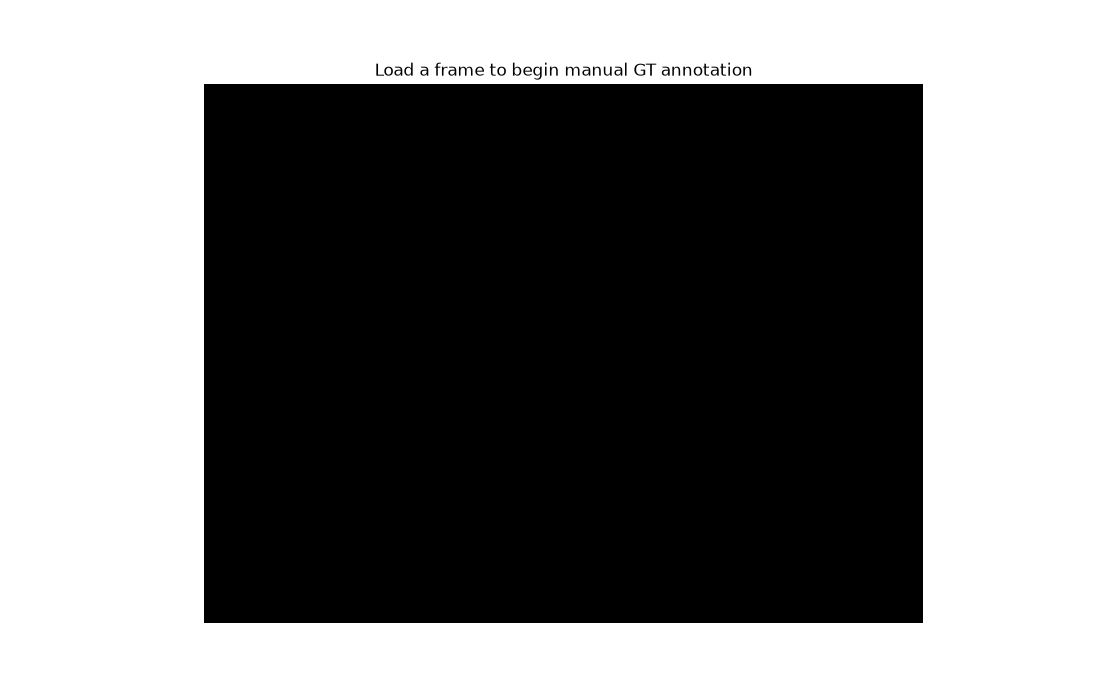

SINGLE_FIGURE_GUI_READY
Chỉ một Figure được tạo; các frame sau cập nhật Figure này.
GT_ID_AUTO_INCREMENT = False
NEW_FRAME_GT_ID_RESET = 1
COPY_PREVIOUS_GT = staging_only_from_previous_REVIEWED_frame


ValueError: Frame must be in 303..352

ValueError: Frame must be in 303..352

ValueError: Frame must be in 947..996

ValueError: Frame must be in 947..996

...

ValueError: Frame must be in 243..292

ValueError: Frame must be in 243..292

ValueError: Frame must be in 243..292

ValueError: Frame must be in 243..292

ValueError: Frame must be in 243..292

In [ ]:
# ============================================================
# 3B. INTERACTIVE MULTI-BBOX GUI — SINGLE FIGURE VERSION
# Một Figure duy nhất được tạo và tái sử dụng cho mọi frame.
# ============================================================

try:
    import ipympl
    import ipywidgets as widgets
    from IPython.display import display
    from matplotlib.widgets import RectangleSelector
    from matplotlib.patches import Rectangle
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    print("ANNOTATION_GUI_DEPENDENCY_MISSING")
    print("Install only: python -m pip install ipympl")
    raise

# ------------------------------------------------------------
# 1. Controls
# ------------------------------------------------------------

SEGMENT_LABELS = [
    (
        f"{s['video_id']} / {s['segment_id']}",
        (s["video_id"], s["segment_id"]),
    )
    for s in EVAL_SEGMENTS
]

segment_dd = widgets.Dropdown(
    options=SEGMENT_LABELS,
    description="Segment:",
)

frame_box = widgets.IntText(
    description="Frame:",
)

gt_id_box = widgets.IntText(
    value=1,
    description="GT ID:",
)

certainty_dd = widgets.Dropdown(
    options=["CERTAIN", "UNCERTAIN"],
    value="CERTAIN",
    description="Certainty:",
)

load_btn = widgets.Button(
    description="Load frame",
)

next_btn = widgets.Button(
    description="Load next unreviewed",
)

copy_prev_btn = widgets.Button(
    description="Copy previous GT",
)

add_btn = widgets.Button(
    description="Add selected bbox",
    button_style="info",
)

remove_btn = widgets.Button(
    description="Remove last",
)

clear_btn = widgets.Button(
    description="Clear staged objects",
)

save_btn = widgets.Button(
    description="Save frame + REVIEWED",
    button_style="success",
)

status = widgets.HTML()
selection_status = widgets.HTML(
    value="<b>No frame loaded.</b>"
)
object_status = widgets.HTML(
    value="<b>Objects in current frame:</b> none"
)

controls = widgets.VBox([
    widgets.HBox([
        segment_dd,
        frame_box,
        load_btn,
        next_btn,
        copy_prev_btn,
    ]),
    widgets.HBox([
        gt_id_box,
        certainty_dd,
        add_btn,
        remove_btn,
        clear_btn,
        save_btn,
    ]),
    status,
    selection_status,
    object_status,
])

# ------------------------------------------------------------
# 2. Create EXACTLY ONE persistent Figure
# ------------------------------------------------------------

plt.close("all")

with plt.ioff():
    FIG, AX = plt.subplots(figsize=(11, 7))

# Hide toolbar so Zoom/Pan cannot interfere with bbox dragging.
for attr in ("toolbar_visible", "header_visible", "footer_visible"):
    if hasattr(FIG.canvas, attr):
        try:
            setattr(FIG.canvas, attr, False)
        except Exception:
            pass

if hasattr(FIG.canvas, "resizable"):
    try:
        FIG.canvas.resizable = False
    except Exception:
        pass

# Initial blank image; updated in place for every frame.
_blank = np.zeros((960, 1280, 3), dtype=np.uint8)
IMAGE_ARTIST = AX.imshow(_blank)

AX.set_title("Load a frame to begin manual GT annotation")
AX.set_axis_off()

# Store manual GT overlays so they can be removed/redrawn without
# creating a new Figure.
DRAWN_ARTISTS = []

# ------------------------------------------------------------
# 3. State
# ------------------------------------------------------------

STATE = {
    "video_id": None,
    "segment_id": None,
    "frame_index": None,
    "objects": [],
    "width": 1280,
    "height": 960,
    "current_bbox": None,
    "selection_valid": False,
}

def _segment_range(video_id, segment_id):
    s = segment_lookup(video_id, segment_id)
    return int(s["start_frame"]), int(s["end_frame"])

def _load_existing_objects(video_id, segment_id, frame_index):
    gt = _load_gt()

    rows = gt[
        gt["video_id"].astype(str).eq(video_id)
        & gt["segment_id"].astype(str).eq(segment_id)
        & gt["frame_index"].eq(int(frame_index))
    ]

    out = []

    for _, r in rows.iterrows():
        out.append({
            "gt_track_id": int(r["gt_track_id"]),
            "x1": float(r["x1"]),
            "y1": float(r["y1"]),
            "x2": float(r["x2"]),
            "y2": float(r["y2"]),
            "identity_certainty": str(r["identity_certainty"]),
            "visibility_note": (
                ""
                if pd.isna(r["visibility_note"])
                else str(r["visibility_note"])
            ),
            "annotation_note": (
                ""
                if pd.isna(r["annotation_note"])
                else str(r["annotation_note"])
            ),
        })

    return out

def _current_review_status(video_id, segment_id, frame_index):
    review = _load_review()

    row = review[
        review["video_id"].astype(str).eq(video_id)
        & review["segment_id"].astype(str).eq(segment_id)
        & review["frame_index"].eq(int(frame_index))
    ]

    if len(row) != 1:
        return "UNKNOWN"

    return str(row.iloc[0]["review_status"]).upper()

def _progress_html(video_id, segment_id):
    review = _load_review()

    sub = review[
        review["video_id"].astype(str).eq(video_id)
        & review["segment_id"].astype(str).eq(segment_id)
    ]

    reviewed = int(
        sub["review_status"]
        .astype(str)
        .str.upper()
        .eq("REVIEWED")
        .sum()
    )

    total = len(sub)

    gt = _load_active_gt()

    objects = len(
        gt[
            gt["video_id"].astype(str).eq(video_id)
            & gt["segment_id"].astype(str).eq(segment_id)
        ]
    )

    return (
        f"<b>{video_id}/{segment_id}</b> — "
        f"reviewed {reviewed}/{total}, "
        f"remaining {total-reviewed}, "
        f"GT objects {objects}"
    )

def _objects_html():
    if not STATE["objects"]:
        return "<b>Objects in current frame:</b> none"

    lines = ["<b>Objects in current frame:</b>"]

    for i, obj in enumerate(STATE["objects"], 1):
        lines.append(
            f"{i}. GT {int(obj['gt_track_id'])}: "
            f"({int(obj['x1'])}, {int(obj['y1'])}) → "
            f"({int(obj['x2'])}, {int(obj['y2'])}), "
            f"{obj['identity_certainty']}"
        )

    return "<br>".join(lines)

def _clear_drawn_artists():
    global DRAWN_ARTISTS

    for artist in DRAWN_ARTISTS:
        try:
            artist.remove()
        except Exception:
            pass

    DRAWN_ARTISTS = []

def _redraw_manual_objects():
    _clear_drawn_artists()

    for obj in STATE["objects"]:
        rect = Rectangle(
            (obj["x1"], obj["y1"]),
            obj["x2"] - obj["x1"],
            obj["y2"] - obj["y1"],
            fill=False,
            linewidth=2,
        )

        AX.add_patch(rect)
        DRAWN_ARTISTS.append(rect)

        label = AX.text(
            obj["x1"],
            max(0, obj["y1"] - 6),
            f"GT {int(obj['gt_track_id'])}",
            fontsize=9,
        )

        DRAWN_ARTISTS.append(label)

    object_status.value = _objects_html()

    FIG.canvas.draw_idle()

def _reset_selection(message=None):
    STATE["current_bbox"] = None
    STATE["selection_valid"] = False

    if "RECT_SELECTOR" in globals():
        try:
            RECT_SELECTOR.extents = (-10, -9, -10, -9)
        except Exception:
            pass

    if message is None:
        message = (
            "<b>No bbox selected.</b> "
            "Kéo chuột trái trực tiếp trên ảnh."
        )

    selection_status.value = message

# ------------------------------------------------------------
# 4. One persistent RectangleSelector
# ------------------------------------------------------------

def _selection_callback(eclick, erelease):
    if STATE["frame_index"] is None:
        _reset_selection("<b>Load a frame first.</b>")
        return

    if (
        eclick.xdata is None
        or eclick.ydata is None
        or erelease.xdata is None
        or erelease.ydata is None
    ):
        _reset_selection("<b>INVALID_SELECTION</b>")
        return

    width = int(STATE["width"])
    height = int(STATE["height"])

    x1 = int(round(min(eclick.xdata, erelease.xdata)))
    y1 = int(round(min(eclick.ydata, erelease.ydata)))
    x2 = int(round(max(eclick.xdata, erelease.xdata)))
    y2 = int(round(max(eclick.ydata, erelease.ydata)))

    x1 = max(0, min(x1, width - 1))
    y1 = max(0, min(y1, height - 1))
    x2 = max(1, min(x2, width))
    y2 = max(1, min(y2, height))

    # Reject default selector extents / accidental clicks.
    if (x2 - x1) < 5 or (y2 - y1) < 5:
        _reset_selection(
            "<b>BBOX TOO SMALL / INVALID.</b> "
            "Kéo lại bbox quanh cá."
        )
        return

    STATE["current_bbox"] = {
        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2,
    }

    STATE["selection_valid"] = True

    selection_status.value = (
        f"<b>Selected bbox:</b> "
        f"x1={x1}, y1={y1}, x2={x2}, y2={y2}. "
        "Nếu đúng, bấm <b>Add selected bbox</b>."
    )

RECT_SELECTOR = RectangleSelector(
    AX,
    _selection_callback,
    useblit=False,
    button=[1],
    minspanx=5,
    minspany=5,
    spancoords="pixels",
    interactive=True,
)

RECT_SELECTOR.set_active(False)

# ------------------------------------------------------------
# 5. Frame loading: update the SAME Figure only
# ------------------------------------------------------------

def load_frame(video_id, segment_id, frame_index):
    start, end = _segment_range(video_id, segment_id)
    frame_index = int(frame_index)

    if not (start <= frame_index <= end):
        raise ValueError(
            f"Frame must be in {start}..{end}"
        )

    path = raw_frame_path(
        video_id,
        segment_id,
        frame_index,
    )

    img_bgr = cv2.imread(str(path))

    if img_bgr is None:
        raise FileNotFoundError(path)

    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB,
    )

    height, width = img_rgb.shape[:2]

    existing = _load_existing_objects(
        video_id,
        segment_id,
        frame_index,
    )

    STATE.update({
        "video_id": video_id,
        "segment_id": segment_id,
        "frame_index": frame_index,
        "objects": existing,
        "width": width,
        "height": height,
    })

    frame_box.value = frame_index

    # Mỗi frame mới bắt đầu từ GT ID = 1.
    # Sau đó USER tự đổi ID nếu frame có nhiều cá.
    gt_id_box.value = 1

    # Reuse one AxesImage; do not create any new Figure.
    IMAGE_ARTIST.set_data(img_rgb)

    AX.set_xlim(0, width)
    AX.set_ylim(height, 0)
    AX.set_axis_off()

    review_state = _current_review_status(
        video_id,
        segment_id,
        frame_index,
    )

    AX.set_title(
        f"RAW GT — {video_id}/{segment_id} — frame {frame_index}\n"
        f"review_status={review_state}"
    )

    _reset_selection()

    RECT_SELECTOR.set_active(True)

    _redraw_manual_objects()

    status.value = _progress_html(
        video_id,
        segment_id,
    )

    if existing and review_state != "REVIEWED":
        selection_status.value = (
            f"<b>Loaded {len(existing)} existing GT object(s) "
            "from a previous manual attempt.</b> "
            "Giữ nếu đúng, vẽ lại cùng GT ID để thay, "
            "hoặc Clear staged objects."
        )

    FIG.canvas.draw_idle()

# ------------------------------------------------------------
# 6. Button callbacks
# ------------------------------------------------------------

def _on_segment_change(change):
    if change["name"] == "value" and change["new"] is not None:
        video_id, segment_id = change["new"]

        start, _ = _segment_range(
            video_id,
            segment_id,
        )

        frame_box.value = start
        gt_id_box.value = 1

        status.value = _progress_html(
            video_id,
            segment_id,
        )

segment_dd.observe(_on_segment_change)

def _load_clicked(_):
    video_id, segment_id = segment_dd.value

    load_frame(
        video_id,
        segment_id,
        frame_box.value,
    )

def _next_unreviewed_clicked(_):
    video_id, segment_id = segment_dd.value

    review = _load_review()

    sub = review[
        review["video_id"].astype(str).eq(video_id)
        & review["segment_id"].astype(str).eq(segment_id)
        & ~review["review_status"]
            .astype(str)
            .str.upper()
            .eq("REVIEWED")
    ].sort_values("frame_index")

    if sub.empty:
        status.value = (
            _progress_html(video_id, segment_id)
            + " — <b>SEGMENT COMPLETE</b>"
        )
        return

    load_frame(
        video_id,
        segment_id,
        int(sub.iloc[0]["frame_index"]),
    )


def _copy_previous_clicked(_):
    """
    Copy GT objects from the nearest previous REVIEWED frame
    in the same segment into the current staging area.

    IMPORTANT:
    - does NOT write GT CSV;
    - does NOT mark the current frame REVIEWED;
    - does NOT use detector/tracker predictions.
    """

    if STATE["frame_index"] is None:
        selection_status.value = (
            "<b>Load a frame first.</b>"
        )
        return

    video_id = STATE["video_id"]
    segment_id = STATE["segment_id"]
    current_frame = int(STATE["frame_index"])

    review = _load_review()

    previous = review[
        review["video_id"].astype(str).eq(video_id)
        & review["segment_id"].astype(str).eq(segment_id)
        & review["frame_index"].lt(current_frame)
        & review["review_status"]
            .astype(str)
            .str.upper()
            .eq("REVIEWED")
    ].sort_values(
        "frame_index",
        ascending=False,
    )

    if previous.empty:
        selection_status.value = (
            "<b>No previous REVIEWED frame exists in this segment.</b>"
        )
        return

    previous_frame = int(
        previous.iloc[0]["frame_index"]
    )

    copied = _load_existing_objects(
        video_id,
        segment_id,
        previous_frame,
    )

    STATE["objects"] = [
        dict(obj)
        for obj in copied
    ]

    gt_id_box.value = 1

    _redraw_manual_objects()

    _reset_selection(
        f"<b>Copied {len(copied)} GT object(s) from reviewed "
        f"frame {previous_frame}.</b> "
        "Đây chỉ là staging. Kiểm tra/chỉnh bbox trên raw frame hiện tại "
        "rồi mới bấm Save frame + REVIEWED."
    )


def _add_clicked(_):
    if STATE["frame_index"] is None:
        selection_status.value = (
            "<b>Load a frame first.</b>"
        )
        return

    if (
        not STATE["selection_valid"]
        or STATE["current_bbox"] is None
    ):
        selection_status.value = (
            "<b>NO VALID BBOX.</b> "
            "Kéo chuột quanh cá trước khi bấm Add."
        )
        return

    bbox = dict(
        STATE["current_bbox"]
    )

    tid = int(
        gt_id_box.value
    )

    # Redrawing same GT ID replaces the old staged bbox.
    STATE["objects"] = [
        obj
        for obj in STATE["objects"]
        if int(obj["gt_track_id"]) != tid
    ]

    STATE["objects"].append({
        "gt_track_id": tid,
        **bbox,
        "identity_certainty": certainty_dd.value,
        "visibility_note": "",
        "annotation_note": "",
    })

    _redraw_manual_objects()

    selection_status.value = (
        f"<b>ADDED:</b> GT ID {tid}, "
        f"bbox {bbox}. "
        "<b>GT ID giữ nguyên, không tự tăng.</b>"
    )

    # USER yêu cầu: KHÔNG tự tăng GT ID sau khi Add.
    # Giữ nguyên GT ID hiện tại; USER tự đổi khi gán cá khác.
    gt_id_box.value = tid

    STATE["current_bbox"] = None
    STATE["selection_valid"] = False

def _remove_clicked(_):
    if STATE["objects"]:
        STATE["objects"].pop()

    _redraw_manual_objects()

    _reset_selection(
        "<b>Removed last staged object.</b>"
    )

def _clear_clicked(_):
    STATE["objects"] = []

    _redraw_manual_objects()

    gt_id_box.value = 1

    _reset_selection(
        "<b>All staged objects cleared.</b> "
        "GT CSV chưa thay đổi cho đến khi bạn bấm Save."
    )

def _save_clicked(_):
    if STATE["frame_index"] is None:
        status.value = (
            "<b>Load a frame first.</b>"
        )
        return

    # Extra guard against bad/default tiny boxes.
    for obj in STATE["objects"]:
        if (
            float(obj["x2"]) - float(obj["x1"]) < 5
            or float(obj["y2"]) - float(obj["y1"]) < 5
        ):
            status.value = (
                "<b>SAVE BLOCKED:</b> "
                "Có bbox quá nhỏ/không hợp lệ."
            )
            return

    result = save_frame_gt(
        STATE["video_id"],
        STATE["segment_id"],
        STATE["frame_index"],
        STATE["objects"],
    )

    status.value = (
        _progress_html(
            STATE["video_id"],
            STATE["segment_id"],
        )
        + f" — <b>SAVE_OK:</b> "
        + f"{result['objects_saved']} object(s)"
    )

    _next_unreviewed_clicked(None)

load_btn.on_click(_load_clicked)
next_btn.on_click(_next_unreviewed_clicked)
copy_prev_btn.on_click(_copy_previous_clicked)
add_btn.on_click(_add_clicked)
remove_btn.on_click(_remove_clicked)
clear_btn.on_click(_clear_clicked)
save_btn.on_click(_save_clicked)

# ------------------------------------------------------------
# 7. Initial state + display EXACTLY ONE canvas
# ------------------------------------------------------------

video_id0, segment_id0 = segment_dd.value

start0, _ = _segment_range(
    video_id0,
    segment_id0,
)

frame_box.value = start0

status.value = _progress_html(
    video_id0,
    segment_id0,
)

display(controls)
display(FIG.canvas)

print("SINGLE_FIGURE_GUI_READY")
print("Chỉ một Figure được tạo; các frame sau cập nhật Figure này.")

print("GT_ID_AUTO_INCREMENT = False")
print("NEW_FRAME_GT_ID_RESET = 1")
print("COPY_PREVIOUS_GT = staging_only_from_previous_REVIEWED_frame")


In [13]:

# ============================================================
# 3C. CLEAN KNOWN INVALID 1x1 / TINY GT BOXES
# Chạy một lần trước khi bắt đầu gán nhãn bằng GUI mới.
# ============================================================

gt_check = _load_gt()

if len(gt_check) == 0:
    print("GT file is empty — no invalid rows to clean.")
else:
    bad = (
        (gt_check["x2"] - gt_check["x1"] < 5)
        | (gt_check["y2"] - gt_check["y1"] < 5)
    )

    bad_rows = gt_check.loc[bad].copy()

    print("Saved GT rows with width/height < 5 px:", len(bad_rows))

    if len(bad_rows):
        display(bad_rows)

        gt_clean = gt_check.loc[~bad].copy()
        gt_clean.to_csv(GT_OBJECT_PATH, index=False, na_rep="")

        review = _load_review()

        for _, row in bad_rows.iterrows():
            mask = (
                review["video_id"].astype(str).eq(str(row["video_id"]))
                & review["segment_id"].astype(str).eq(str(row["segment_id"]))
                & review["frame_index"].eq(int(row["frame_index"]))
            )
            review.loc[mask, "review_status"] = "UNREVIEWED"
            review.loc[mask, "review_note"] = pd.NA

        review.to_csv(GT_REVIEW_PATH, index=False, na_rep="")

        print("INVALID_BBOX_ROWS_REMOVED_AND_FRAMES_RESET")
    else:
        print("No invalid saved bbox rows detected.")


Saved GT rows with width/height < 5 px: 0
No invalid saved bbox rows detected.


In [20]:
# ============================================================
# 4. GT QUALITY AUDIT
# ============================================================

review = _load_review()

# Chỉ lấy GT thuộc các segment đang ACTIVE trong Notebook 09
gt = _load_active_gt()

reviewed = int(
    review["review_status"]
    .astype(str)
    .str.upper()
    .eq("REVIEWED")
    .sum()
)

total_review_frames = len(review)
remaining = total_review_frames - reviewed

invalid_bbox_rows = 0
duplicate_rows = 0
uncertain_objects = 0
frames_exceeding_fish_count = 0

# ------------------------------------------------------------
# 1. Kiểm tra GT object
# ------------------------------------------------------------

if len(gt):

    # Thiếu dữ liệu số
    required_numeric = [
        "frame_index",
        "gt_track_id",
        "x1",
        "y1",
        "x2",
        "y2",
    ]

    invalid_bbox_rows += int(
        gt[required_numeric]
        .isna()
        .any(axis=1)
        .sum()
    )

    # Trùng GT ID trong cùng frame
    duplicate_rows = int(
        gt.duplicated(
            [
                "video_id",
                "segment_id",
                "frame_index",
                "gt_track_id",
            ],
            keep=False,
        ).sum()
    )

    # Identity không chắc chắn
    uncertain_objects = int(
        gt["identity_certainty"]
        .astype(str)
        .str.upper()
        .eq("UNCERTAIN")
        .sum()
    )

    # Kiểm tra bbox
    for _, row in gt.iterrows():

        video_id = str(row["video_id"])
        meta = VIDEO_META[video_id]

        x1 = float(row["x1"])
        y1 = float(row["y1"])
        x2 = float(row["x2"])
        y2 = float(row["y2"])

        if not (0 <= x1 < x2 <= meta["width"]):
            invalid_bbox_rows += 1

        if not (0 <= y1 < y2 <= meta["height"]):
            invalid_bbox_rows += 1

        if (x2 - x1) < 5 or (y2 - y1) < 5:
            invalid_bbox_rows += 1

    # Kiểm tra số GT object có vượt số cá thực tế không
    frame_counts = (
        gt.groupby(
            ["video_id", "segment_id", "frame_index"]
        )
        .size()
        .rename("visible_gt_count")
        .reset_index()
    )

    for _, row in frame_counts.iterrows():

        fish_count = int(
            VIDEO_REGISTRY[
                str(row["video_id"])
            ]["fish_count"]
        )

        if int(row["visible_gt_count"]) > fish_count:
            frames_exceeding_fish_count += 1

# ------------------------------------------------------------
# 2. Progress từng segment
# ------------------------------------------------------------

progress = (
    review.groupby(
        ["video_id", "segment_id"],
        as_index=False,
    )
    .agg(
        total_frames=("frame_index", "count"),
        reviewed_frames=(
            "review_status",
            lambda s: int(
                s.astype(str)
                .str.upper()
                .eq("REVIEWED")
                .sum()
            ),
        ),
    )
)

progress["remaining_frames"] = (
    progress["total_frames"]
    - progress["reviewed_frames"]
)

if len(gt):

    obj = (
        gt.groupby(
            ["video_id", "segment_id"]
        )
        .size()
        .rename("GT_object_rows")
        .reset_index()
    )

    progress = progress.merge(
        obj,
        on=["video_id", "segment_id"],
        how="left",
    )

else:
    progress["GT_object_rows"] = 0

progress["GT_object_rows"] = (
    progress["GT_object_rows"]
    .fillna(0)
    .astype(int)
)

display(progress)

# ------------------------------------------------------------
# 3. GT COMPLETE
# ------------------------------------------------------------

GT_COMPLETE = (
    total_review_frames == 200
    and reviewed == 200
    and invalid_bbox_rows == 0
    and duplicate_rows == 0
    and frames_exceeding_fish_count == 0
)

print("========== GT AUDIT SUMMARY ==========")
print("reviewed:", reviewed, "/", total_review_frames)
print("remaining:", remaining)
print("GT object rows:", len(gt))
print("UNCERTAIN objects:", uncertain_objects)
print("invalid bbox rows:", invalid_bbox_rows)
print("duplicate rows:", duplicate_rows)
print(
    "frames exceeding fish_count:",
    frames_exceeding_fish_count,
)
print("GT_COMPLETE:", GT_COMPLETE)

if not GT_COMPLETE:
    print("USER_ACTION_REQUIRED_GROUNDTRUTH")
else:
    print("GROUND_TRUTH_READY_FOR_TRACKER_EVALUATION")

,video_id,segment_id,total_frames,reviewed_frames,remaining_frames,GT_object_rows
0,V3_FEEDING,F1_FEEDING_DENSE,50,50,0,391
1,V4_BREEDING,S2_SHELTER_TRANSITION,50,50,0,39
2,V5_NORMAL,M2_CROSSING,50,50,0,269
3,V8_PAIR_T1,P1_PAIR_INTERACTION,50,50,0,69


========== GT AUDIT SUMMARY ==========
reviewed: 200 / 200
remaining: 0
GT object rows: 768
UNCERTAIN objects: 55
invalid bbox rows: 0
duplicate rows: 0
frames exceeding fish_count: 0
GT_COMPLETE: True
GROUND_TRUTH_READY_FOR_TRACKER_EVALUATION



## 5. Sau khi GT_COMPLETE = True

Quay lại cell CONFIG và đổi:

```python
RUN_TRACKERS = True
```

Sau đó chạy từ cell CONFIG xuống cuối notebook. Không retune tracker.


In [21]:

# ============================================================
# 5. RUN TRACKERS ON SELECTED SEGMENTS
# ============================================================
def run_tracker_segment(tracker_name,tracker_yaml,seg):
    from ultralytics import YOLO
    video_id=seg['video_id']; meta=VIDEO_META[video_id]
    out_dir=PRED_ROOT/tracker_name/video_id; out_dir.mkdir(parents=True,exist_ok=True)
    out_csv=out_dir/f"{seg['segment_id']}_frame_tracks.csv"
    if out_csv.exists(): print('REUSE:',out_csv); return out_csv
    model=YOLO(str(MODEL_PATH)); cap=cv2.VideoCapture(str(meta['path'])); cap.set(cv2.CAP_PROP_POS_FRAMES,seg['start_frame'])
    rows=[]; t0=time.perf_counter()
    for frame_index in range(seg['start_frame'],seg['end_frame']+1):
        ok,frame=cap.read()
        if not ok: raise RuntimeError(f'Cannot read {video_id} frame {frame_index}')
        result=model.track(frame,persist=True,tracker=str(tracker_yaml),conf=DETECTION_FLOOR,imgsz=IMGSZ,device=DEVICE,verbose=False)[0]
        boxes=result.boxes
        if boxes is None or boxes.id is None: continue
        xyxy=boxes.xyxy.detach().cpu().numpy(); ids=boxes.id.detach().cpu().numpy().astype(int); conf=boxes.conf.detach().cpu().numpy(); cls=boxes.cls.detach().cpu().numpy().astype(int)
        for b,tid,cf,cl in zip(xyxy,ids,conf,cls):
            x1,y1,x2,y2=map(float,b); rows.append({'tracker':tracker_name,'video_id':video_id,'segment_id':seg['segment_id'],'frame_index':frame_index,'time_sec':frame_index/meta['fps'],'pred_track_id':tid,'class_id':cl,'confidence':float(cf),'x1':x1,'y1':y1,'x2':x2,'y2':y2})
    cap.release(); pd.DataFrame(rows).to_csv(out_csv,index=False)
    print(tracker_name,video_id,seg['segment_id'],'FPS:',(seg['end_frame']-seg['start_frame']+1)/(time.perf_counter()-t0)); return out_csv

PRED_FILES={}
if GT_COMPLETE and RUN_TRACKERS:
    assert MODEL_PATH.is_file(); assert sha256_file(MODEL_PATH)==EXPECTED_MODEL_SHA256
    for name,cfg in TRACKER_CONFIGS.items():
        assert cfg.is_file(),cfg
        for seg in EVAL_SEGMENTS: PRED_FILES[(name,seg['video_id'],seg['segment_id'])]=run_tracker_segment(name,cfg,seg)
else:
    print('SKIPPED_TRACKER_RUN — cần GT_COMPLETE=True và RUN_TRACKERS=True')


REUSE: /home/diy-hus/fish/outputs/front/mot_eval/predictions/BYTE_B15/V4_BREEDING/S2_SHELTER_TRANSITION_frame_tracks.csv
REUSE: /home/diy-hus/fish/outputs/front/mot_eval/predictions/BYTE_B15/V8_PAIR_T1/P1_PAIR_INTERACTION_frame_tracks.csv
REUSE: /home/diy-hus/fish/outputs/front/mot_eval/predictions/BYTE_B15/V5_NORMAL/M2_CROSSING_frame_tracks.csv
REUSE: /home/diy-hus/fish/outputs/front/mot_eval/predictions/BYTE_B15/V3_FEEDING/F1_FEEDING_DENSE_frame_tracks.csv
REUSE: /home/diy-hus/fish/outputs/front/mot_eval/predictions/BOTSORT/V4_BREEDING/S2_SHELTER_TRANSITION_frame_tracks.csv
REUSE: /home/diy-hus/fish/outputs/front/mot_eval/predictions/BOTSORT/V8_PAIR_T1/P1_PAIR_INTERACTION_frame_tracks.csv
REUSE: /home/diy-hus/fish/outputs/front/mot_eval/predictions/BOTSORT/V5_NORMAL/M2_CROSSING_frame_tracks.csv
REUSE: /home/diy-hus/fish/outputs/front/mot_eval/predictions/BOTSORT/V3_FEEDING/F1_FEEDING_DENSE_frame_tracks.csv


In [22]:

# ============================================================
# 6. LAPJV MATCHING @ IoU 0.50
# ============================================================
def bbox_iou_matrix(g,p):
    g=np.asarray(g,float); p=np.asarray(p,float)
    if len(g)==0 or len(p)==0: return np.zeros((len(g),len(p)))
    ix1=np.maximum(g[:,None,0],p[None,:,0]); iy1=np.maximum(g[:,None,1],p[None,:,1]); ix2=np.minimum(g[:,None,2],p[None,:,2]); iy2=np.minimum(g[:,None,3],p[None,:,3])
    inter=np.maximum(0,ix2-ix1)*np.maximum(0,iy2-iy1); ga=(g[:,2]-g[:,0])*(g[:,3]-g[:,1]); pa=(p[:,2]-p[:,0])*(p[:,3]-p[:,1]); union=ga[:,None]+pa[None,:]-inter
    return np.divide(inter,union,out=np.zeros_like(inter),where=union>0)

def lapjv_match(iou,threshold=0.50):
    if iou.size==0: return []
    import lap
    _,x,_=lap.lapjv(1.0-iou,extend_cost=True,cost_limit=1.0-threshold)
    return [(gi,int(pj),float(iou[gi,pj])) for gi,pj in enumerate(x) if pj>=0 and pj<iou.shape[1] and iou[gi,pj]>=threshold]

def evaluate_one(tracker_name,seg,pred_csv):
    gtall=_load_gt(); gtseg=gtall[gtall['video_id'].astype(str).eq(seg['video_id'])&gtall['segment_id'].astype(str).eq(seg['segment_id'])].copy(); pred=pd.read_csv(pred_csv) if Path(pred_csv).exists() else pd.DataFrame()
    total_gt=total_pred=matched=0; ious=[]; matches=[]
    for fi in range(seg['start_frame'],seg['end_frame']+1):
        g=gtseg[gtseg['frame_index'].eq(fi)].reset_index(drop=True); p=pred[pred['frame_index'].eq(fi)].reset_index(drop=True) if len(pred) else pd.DataFrame()
        gb=g[['x1','y1','x2','y2']].to_numpy(float) if len(g) else np.empty((0,4)); pb=p[['x1','y1','x2','y2']].to_numpy(float) if len(p) else np.empty((0,4))
        pairs=lapjv_match(bbox_iou_matrix(gb,pb),MATCH_IOU_THRESHOLD); total_gt+=len(g); total_pred+=len(p); matched+=len(pairs)
        for gi,pj,iv in pairs: ious.append(iv); matches.append({'frame_index':fi,'gt_track_id':int(g.iloc[gi]['gt_track_id']),'identity_certainty':str(g.iloc[gi]['identity_certainty']),'pred_track_id':int(p.iloc[pj]['pred_track_id']),'iou':iv})
    m=pd.DataFrame(matches); id_changes=0
    if len(m):
        certain=m[m['identity_certainty'].str.upper().eq('CERTAIN')]
        for _,sub in certain.groupby('gt_track_id'):
            sub=sub.sort_values('frame_index'); prev=None
            for _,r in sub.iterrows():
                cur=int(r['pred_track_id']); id_changes += int(prev is not None and cur!=prev); prev=cur
    return {'tracker':tracker_name,'video_id':seg['video_id'],'segment_id':seg['segment_id'],'group':VIDEO_REGISTRY[seg['video_id']]['group'],'scenario':seg['scenario'],'gt_objects':total_gt,'pred_objects':total_pred,'matched_objects':matched,'unmatched_gt':total_gt-matched,'unmatched_predictions':total_pred-matched,'match_precision':matched/total_pred if total_pred else np.nan,'match_recall':matched/total_gt if total_gt else np.nan,'mean_matched_iou':float(np.mean(ious)) if ious else np.nan,'gt_pred_id_changes_diagnostic':id_changes,'matching':'LAPJV','match_iou_threshold':MATCH_IOU_THRESHOLD}

BY_SEGMENT=pd.DataFrame()
if GT_COMPLETE and RUN_TRACKERS:
    rows=[]
    for name in TRACKER_CONFIGS:
        for seg in EVAL_SEGMENTS: rows.append(evaluate_one(name,seg,PRED_FILES[(name,seg['video_id'],seg['segment_id'])]))
    BY_SEGMENT=pd.DataFrame(rows); path=RESULTS_DIR/'front_mot_tracker_eval_by_segment.csv'; BY_SEGMENT.to_csv(path,index=False); display(BY_SEGMENT); print('Saved:',path)
else: print('SKIPPED_EVALUATION')


,tracker,video_id,segment_id,group,scenario,gt_objects,pred_objects,matched_objects,unmatched_gt,unmatched_predictions,match_precision,match_recall,mean_matched_iou,gt_pred_id_changes_diagnostic,matching,match_iou_threshold
0,BYTE_B15,V4_BREEDING,S2_SHELTER_TRANSITION,SINGLE_FISH_BREEDING,SHELTER_APPROACH,39,27,26,13,1,0.962963,0.666667,0.630583,0,LAPJV,0.5
1,BYTE_B15,V8_PAIR_T1,P1_PAIR_INTERACTION,MULTI_FISH_PAIR,PAIR_INTERACTION,69,36,30,39,6,0.833333,0.434783,0.674330,0,LAPJV,0.5
2,BYTE_B15,V5_NORMAL,M2_CROSSING,MULTI_FISH_NORMAL,CROSSING,269,241,191,78,50,0.792531,0.710037,0.626985,1,LAPJV,0.5
3,BYTE_B15,V3_FEEDING,F1_FEEDING_DENSE,MULTI_FISH_FEEDING,FEEDING_DENSE,391,287,176,215,111,0.613240,0.450128,0.626912,1,LAPJV,0.5
4,BOTSORT,V4_BREEDING,S2_SHELTER_TRANSITION,SINGLE_FISH_BREEDING,SHELTER_APPROACH,39,27,25,14,2,0.925926,0.641026,0.640206,0,LAPJV,0.5
5,BOTSORT,V8_PAIR_T1,P1_PAIR_INTERACTION,MULTI_FISH_PAIR,PAIR_INTERACTION,69,36,29,40,7,0.805556,0.420290,0.669245,0,LAPJV,0.5
6,BOTSORT,V5_NORMAL,M2_CROSSING,MULTI_FISH_NORMAL,CROSSING,269,242,195,74,47,0.805785,0.724907,0.607350,0,LAPJV,0.5
7,BOTSORT,V3_FEEDING,F1_FEEDING_DENSE,MULTI_FISH_FEEDING,FEEDING_DENSE,391,288,184,207,104,0.638889,0.470588,0.607066,1,LAPJV,0.5


Saved: /home/diy-hus/fish/results/tracking/front_mot_tracker_eval_by_segment.csv


In [23]:
# ============================================================
# 6A. GT FRAME-COUNT SANITY AUDIT
# ============================================================

review = _load_review()
gt = _load_active_gt()

rows = []

for seg in EVAL_SEGMENTS:

    video_id = seg["video_id"]
    segment_id = seg["segment_id"]

    frame_list = list(
        range(
            seg["start_frame"],
            seg["end_frame"] + 1
        )
    )

    sub = gt[
        gt["video_id"].astype(str).eq(video_id)
        & gt["segment_id"].astype(str).eq(segment_id)
    ]

    counts = (
        sub.groupby("frame_index")
        .size()
        .reindex(frame_list, fill_value=0)
    )

    rows.append({
        "video_id": video_id,
        "segment_id": segment_id,
        "fish_count_declared":
            VIDEO_REGISTRY[video_id]["fish_count"],
        "frames": len(frame_list),
        "GT_objects": int(counts.sum()),
        "mean_GT_per_frame": float(counts.mean()),
        "zero_object_frames": int((counts == 0).sum()),
        "one_object_frames": int((counts == 1).sum()),
        "max_GT_in_frame": int(counts.max()),
        "unique_GT_IDs": sorted(
            sub["gt_track_id"]
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
    })

GT_COUNT_AUDIT = pd.DataFrame(rows)

display(GT_COUNT_AUDIT)

,video_id,segment_id,fish_count_declared,frames,GT_objects,mean_GT_per_frame,zero_object_frames,one_object_frames,max_GT_in_frame,unique_GT_IDs
0,V4_BREEDING,S2_SHELTER_TRANSITION,1,50,39,0.78,11,39,1,[1]
1,V8_PAIR_T1,P1_PAIR_INTERACTION,2,50,69,1.38,11,9,2,"[1, 2]"
2,V5_NORMAL,M2_CROSSING,8,50,269,5.38,0,0,6,"[1, 2, 3, 4, 5, 6]"
3,V3_FEEDING,F1_FEEDING_DENSE,8,50,391,7.82,1,0,8,"[1, 2, 3, 4, 5, 6, 7, 8]"


In [24]:

# ============================================================
# 7. GROUP RESULTS + SUMMARY
# ============================================================
if GT_COMPLETE and RUN_TRACKERS and len(BY_SEGMENT):
    rows=[]
    for (tracker,group),sub in BY_SEGMENT.groupby(['tracker','group']):
        gt_sum=int(sub['gt_objects'].sum()); pr_sum=int(sub['pred_objects'].sum()); mt=int(sub['matched_objects'].sum())
        valid=sub['mean_matched_iou'].notna()&sub['matched_objects'].gt(0)
        mean_iou=np.average(sub.loc[valid,'mean_matched_iou'],weights=sub.loc[valid,'matched_objects']) if valid.any() else np.nan
        rows.append({'tracker':tracker,'group':group,'gt_objects':gt_sum,'pred_objects':pr_sum,'matched_objects':mt,'unmatched_gt':int(sub['unmatched_gt'].sum()),'unmatched_predictions':int(sub['unmatched_predictions'].sum()),'match_precision':mt/pr_sum if pr_sum else np.nan,'match_recall':mt/gt_sum if gt_sum else np.nan,'mean_matched_iou':mean_iou,'gt_pred_id_changes_diagnostic':int(sub['gt_pred_id_changes_diagnostic'].sum())})
    BY_GROUP=pd.DataFrame(rows); group_path=RESULTS_DIR/'front_mot_tracker_eval_by_group.csv'; BY_GROUP.to_csv(group_path,index=False); display(BY_GROUP)
    summary={'experiment_id':EXPERIMENT_ID,'selected_frames':200,'gt_object_rows':int(len(_load_active_gt())),'match_iou_threshold':MATCH_IOU_THRESHOLD,'matching':'LAPJV','HOTA':None,'note':'HOTA not hand-implemented; track_id is not biological identity.'}
    LOG_DIR.mkdir(parents=True,exist_ok=True); (LOG_DIR/'summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
    print('FINAL SUMMARY'); print(json.dumps(summary,ensure_ascii=False,indent=2))
else:
    print('SKIPPED_RESULTS_AND_SUMMARY')
    if not GT_COMPLETE: print('USER_ACTION_REQUIRED_GROUNDTRUTH')
    elif not RUN_TRACKERS: print('Set RUN_TRACKERS=True after GT is complete.')


,tracker,group,gt_objects,pred_objects,matched_objects,unmatched_gt,unmatched_predictions,match_precision,match_recall,mean_matched_iou,gt_pred_id_changes_diagnostic
0,BOTSORT,MULTI_FISH_FEEDING,391,288,184,207,104,0.638889,0.470588,0.607066,1
1,BOTSORT,MULTI_FISH_NORMAL,269,242,195,74,47,0.805785,0.724907,0.607350,0
2,BOTSORT,MULTI_FISH_PAIR,69,36,29,40,7,0.805556,0.420290,0.669245,0
3,BOTSORT,SINGLE_FISH_BREEDING,39,27,25,14,2,0.925926,0.641026,0.640206,0
4,BYTE_B15,MULTI_FISH_FEEDING,391,287,176,215,111,0.613240,0.450128,0.626912,1
5,BYTE_B15,MULTI_FISH_NORMAL,269,241,191,78,50,0.792531,0.710037,0.626985,1
6,BYTE_B15,MULTI_FISH_PAIR,69,36,30,39,6,0.833333,0.434783,0.674330,0
7,BYTE_B15,SINGLE_FISH_BREEDING,39,27,26,13,1,0.962963,0.666667,0.630583,0


FINAL SUMMARY
{
  "experiment_id": "FRONT_MOT_GT_EVAL_001",
  "selected_frames": 200,
  "gt_object_rows": 768,
  "match_iou_threshold": 0.5,
  "matching": "LAPJV",
  "HOTA": null,
  "note": "HOTA not hand-implemented; track_id is not biological identity."
}


In [26]:
# ============================================================
# 7. OFFICIAL MOT METRICS — py-motmetrics
# ============================================================
#
# Mục tiêu:
# - Tính MOTA, MOTP, IDF1, IDP, IDR, IDSW, FRAG
# - Dùng GT ACTIVE hiện tại
# - IoU threshold = 0.50
# - Segment có identity UNCERTAIN:
#       KHÔNG báo official identity metrics
#       để tránh biến identity không chắc chắn thành GT tuyệt đối
#
# Lưu ý:
# - Không chạy lại detector/tracker ở cell này.
# - Không tính HOTA thủ công.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

try:
    import motmetrics as mm
except ImportError:
    print("MOTMETRICS_NOT_INSTALLED")
    print("Cài thủ công trong env fish:")
    print("python -m pip install motmetrics")
    raise


print("motmetrics version:", getattr(mm, "__version__", "unknown"))


# ------------------------------------------------------------
# 1. Helper: lấy prediction CSV đã tạo ở Cell 5
# ------------------------------------------------------------

def get_pred_csv(tracker_name, seg):

    key = (
        tracker_name,
        seg["video_id"],
        seg["segment_id"],
    )

    # Ưu tiên PRED_FILES đã tạo ở Cell 5
    if (
        "PRED_FILES" in globals()
        and key in PRED_FILES
    ):
        path = Path(PRED_FILES[key])

        if path.exists():
            return path

    # Fallback theo cấu trúc output của Notebook 09
    path = (
        PRED_ROOT
        / tracker_name
        / seg["video_id"]
        / f"{seg['segment_id']}_frame_tracks.csv"
    )

    if not path.exists():
        raise FileNotFoundError(
            f"Prediction CSV not found: {path}"
        )

    return path


# ------------------------------------------------------------
# 2. Official evaluation cho một tracker × segment
# ------------------------------------------------------------

def evaluate_official_mot(
    tracker_name,
    seg,
):

    video_id = seg["video_id"]
    segment_id = seg["segment_id"]

    # Chỉ dùng GT thuộc benchmark ACTIVE
    gt_all = _load_active_gt()

    gt_seg = gt_all[
        gt_all["video_id"]
        .astype(str)
        .eq(video_id)
        &
        gt_all["segment_id"]
        .astype(str)
        .eq(segment_id)
    ].copy()

    # --------------------------------------------------------
    # Identity uncertainty audit
    # --------------------------------------------------------

    uncertain_objects = int(
        gt_seg["identity_certainty"]
        .astype(str)
        .str.upper()
        .eq("UNCERTAIN")
        .sum()
    )

    # Conservative rule:
    # Nếu segment có GT identity UNCERTAIN,
    # không báo official identity-based MOT metrics.
    if uncertain_objects > 0:

        return {
            "tracker": tracker_name,
            "video_id": video_id,
            "segment_id": segment_id,
            "group": VIDEO_REGISTRY[
                video_id
            ]["group"],
            "scenario": seg["scenario"],

            "GT_objects": int(len(gt_seg)),
            "UNCERTAIN_objects": uncertain_objects,

            "MOTA": np.nan,
            "MOTP_distance": np.nan,
            "MOTP_IoU_equiv": np.nan,

            "IDF1": np.nan,
            "IDP": np.nan,
            "IDR": np.nan,

            "IDSW": np.nan,
            "FRAG": np.nan,

            "MOT_precision": np.nan,
            "MOT_recall": np.nan,

            "misses": np.nan,
            "false_positives": np.nan,

            "official_status":
                "SKIPPED_IDENTITY_UNCERTAIN",
        }

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    pred_csv = get_pred_csv(
        tracker_name,
        seg,
    )

    pred = pd.read_csv(
        pred_csv
    )

    # --------------------------------------------------------
    # MOTAccumulator
    # --------------------------------------------------------

    acc = mm.MOTAccumulator(
        auto_id=False
    )

    for frame_index in range(
        int(seg["start_frame"]),
        int(seg["end_frame"]) + 1,
    ):

        g = (
            gt_seg[
                gt_seg["frame_index"]
                .eq(frame_index)
            ]
            .reset_index(drop=True)
        )

        p = (
            pred[
                pred["frame_index"]
                .eq(frame_index)
            ]
            .reset_index(drop=True)
        )

        # Ground-truth biological IDs
        gt_ids = (
            g["gt_track_id"]
            .astype(int)
            .tolist()
            if len(g)
            else []
        )

        # Prediction tracker IDs
        pred_ids = (
            p["pred_track_id"]
            .astype(int)
            .tolist()
            if len(p)
            else []
        )

        gt_boxes = (
            g[
                ["x1", "y1", "x2", "y2"]
            ]
            .to_numpy(float)
            if len(g)
            else np.empty((0, 4))
        )

        pred_boxes = (
            p[
                ["x1", "y1", "x2", "y2"]
            ]
            .to_numpy(float)
            if len(p)
            else np.empty((0, 4))
        )

        # ----------------------------------------------------
        # IoU matrix
        # ----------------------------------------------------

        iou = bbox_iou_matrix(
            gt_boxes,
            pred_boxes,
        )

        # motmetrics cần DISTANCE, không phải similarity.
        # distance = 1 - IoU
        if iou.size:

            distances = (
                1.0 - iou
            )

            # IoU < 0.50 => không được phép match
            distances[
                iou
                < MATCH_IOU_THRESHOLD
            ] = np.nan

        else:

            distances = np.empty(
                (
                    len(gt_ids),
                    len(pred_ids),
                ),
                dtype=float,
            )

        acc.update(
            gt_ids,
            pred_ids,
            distances,
            frameid=int(frame_index),
        )

    # --------------------------------------------------------
    # Compute official metrics
    # --------------------------------------------------------

    mh = mm.metrics.create()

    metrics = [
        "mota",
        "motp",

        "idf1",
        "idp",
        "idr",

        "num_switches",
        "num_fragmentations",

        "precision",
        "recall",

        "num_misses",
        "num_false_positives",

        "num_objects",
    ]

    summary = mh.compute(
        acc,
        metrics=metrics,
        name="segment",
    )

    mota = float(
        summary.loc[
            "segment",
            "mota",
        ]
    )

    motp_distance = float(
        summary.loc[
            "segment",
            "motp",
        ]
    )

    # Vì distance = 1 - IoU,
    # chuyển MOTP distance sang overlap dễ diễn giải hơn.
    motp_iou_equiv = (
        1.0 - motp_distance
        if np.isfinite(motp_distance)
        else np.nan
    )

    return {
        "tracker": tracker_name,
        "video_id": video_id,
        "segment_id": segment_id,
        "group": VIDEO_REGISTRY[
            video_id
        ]["group"],
        "scenario": seg["scenario"],

        "GT_objects": int(
            summary.loc[
                "segment",
                "num_objects",
            ]
        ),

        "UNCERTAIN_objects": 0,

        "MOTA": mota,

        # py-motmetrics trả MOTP dưới dạng distance
        "MOTP_distance":
            motp_distance,

        # Dễ diễn giải trong bài:
        # càng cao càng tốt
        "MOTP_IoU_equiv":
            motp_iou_equiv,

        "IDF1": float(
            summary.loc[
                "segment",
                "idf1",
            ]
        ),

        "IDP": float(
            summary.loc[
                "segment",
                "idp",
            ]
        ),

        "IDR": float(
            summary.loc[
                "segment",
                "idr",
            ]
        ),

        "IDSW": int(
            summary.loc[
                "segment",
                "num_switches",
            ]
        ),

        "FRAG": int(
            summary.loc[
                "segment",
                "num_fragmentations",
            ]
        ),

        "MOT_precision": float(
            summary.loc[
                "segment",
                "precision",
            ]
        ),

        "MOT_recall": float(
            summary.loc[
                "segment",
                "recall",
            ]
        ),

        "misses": int(
            summary.loc[
                "segment",
                "num_misses",
            ]
        ),

        "false_positives": int(
            summary.loc[
                "segment",
                "num_false_positives",
            ]
        ),

        "official_status": "OK",
    }


# ------------------------------------------------------------
# 3. Run all tracker × segment
# ------------------------------------------------------------

official_rows = []

if GT_COMPLETE and RUN_TRACKERS:

    for tracker_name in TRACKER_CONFIGS:

        for seg in EVAL_SEGMENTS:

            row = evaluate_official_mot(
                tracker_name,
                seg,
            )

            official_rows.append(
                row
            )


    OFFICIAL_BY_SEGMENT = pd.DataFrame(
        official_rows
    )


    # --------------------------------------------------------
    # 4. Save results
    # --------------------------------------------------------

    official_path = (
        RESULTS_DIR
        / "front_mot_official_metrics_by_segment.csv"
    )

    OFFICIAL_BY_SEGMENT.to_csv(
        official_path,
        index=False,
    )


    # --------------------------------------------------------
    # 5. Display
    # --------------------------------------------------------

    display(
        OFFICIAL_BY_SEGMENT
    )

    print(
        "Saved:",
        official_path
    )

    print()
    print(
        "Official metric library: py-motmetrics"
    )

    print(
        "IoU matching threshold:",
        MATCH_IOU_THRESHOLD
    )

    print(
        "HOTA: NOT COMPUTED IN THIS CELL"
    )

    print(
        "Segments with UNCERTAIN identity "
        "are conservatively excluded "
        "from official identity metrics."
    )

else:

    print(
        "SKIPPED_OFFICIAL_MOT_METRICS"
    )

    print(
        "Requirement: "
        "GT_COMPLETE=True and RUN_TRACKERS=True"
    )

motmetrics version: 1.4.0


,tracker,video_id,segment_id,group,scenario,GT_objects,UNCERTAIN_objects,MOTA,MOTP_distance,MOTP_IoU_equiv,IDF1,IDP,IDR,IDSW,FRAG,MOT_precision,MOT_recall,misses,false_positives,official_status
0,BYTE_B15,V4_BREEDING,S2_SHELTER_TRANSITION,SINGLE_FISH_BREEDING,SHELTER_APPROACH,39,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SKIPPED_IDENTITY_UNCERTAIN
1,BYTE_B15,V8_PAIR_T1,P1_PAIR_INTERACTION,MULTI_FISH_PAIR,PAIR_INTERACTION,69,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SKIPPED_IDENTITY_UNCERTAIN
2,BYTE_B15,V5_NORMAL,M2_CROSSING,MULTI_FISH_NORMAL,CROSSING,269,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SKIPPED_IDENTITY_UNCERTAIN
3,BYTE_B15,V3_FEEDING,F1_FEEDING_DENSE,MULTI_FISH_FEEDING,FEEDING_DENSE,391,0,0.163683,0.373088,0.626912,0.513274,0.606272,0.445013,1.0,20.0,0.613240,0.450128,215.0,111.0,OK
4,BOTSORT,V4_BREEDING,S2_SHELTER_TRANSITION,SINGLE_FISH_BREEDING,SHELTER_APPROACH,39,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SKIPPED_IDENTITY_UNCERTAIN
5,BOTSORT,V8_PAIR_T1,P1_PAIR_INTERACTION,MULTI_FISH_PAIR,PAIR_INTERACTION,69,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SKIPPED_IDENTITY_UNCERTAIN
6,BOTSORT,V5_NORMAL,M2_CROSSING,MULTI_FISH_NORMAL,CROSSING,269,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SKIPPED_IDENTITY_UNCERTAIN
7,BOTSORT,V3_FEEDING,F1_FEEDING_DENSE,MULTI_FISH_FEEDING,FEEDING_DENSE,391,0,0.202046,0.392934,0.607066,0.536082,0.631944,0.465473,1.0,21.0,0.638889,0.470588,207.0,104.0,OK


Saved: /home/diy-hus/fish/results/tracking/front_mot_official_metrics_by_segment.csv

Official metric library: py-motmetrics
IoU matching threshold: 0.5
HOTA: NOT COMPUTED IN THIS CELL
Segments with UNCERTAIN identity are conservatively excluded from official identity metrics.
